### 0) Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [59]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

#### Load data + basic info

In [60]:
df = pd.read_csv("Dataset.csv")

print("Shape:", df.shape)
print(df.info())
print(df["SepsisLabel"].value_counts())
print(df["SepsisLabel"].value_counts(normalize=True))

Shape: (1552210, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1552210 non-null  int64  
 1   Hour              1552210 non-null  int64  
 2   HR                1398811 non-null  float64
 3   O2Sat             1349474 non-null  float64
 4   Temp              525226 non-null   float64
 5   SBP               1325945 non-null  float64
 6   MAP               1358940 non-null  float64
 7   DBP               1065656 non-null  float64
 8   Resp              1313875 non-null  float64
 9   EtCO2             57636 non-null    float64
 10  BaseExcess        84145 non-null    float64
 11  HCO3              65028 non-null    float64
 12  FiO2              129365 non-null   float64
 13  pH                107573 non-null   float64
 14  PaCO2             86301 non-null    float64
 15  SaO2              53561 non-

In [61]:
# 1) Separate features and target
X = df.drop("SepsisLabel", axis=1)
y = df["SepsisLabel"]

# 2) Drop rows where target is NaN
mask = y.notna()
X = X[mask]
y = y[mask]
print("Step A: y NaN after drop:", y.isna().sum())

print("Step B: shape after dropping NaN y:", X.shape)

# 3) Drop constant columns
nunique = X.nunique()
constant_cols = nunique[nunique <= 1].index
print("Step C: constant columns:", list(constant_cols))
X = X.drop(columns=constant_cols)

# 4) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
feature_names_original = X_train.columns.tolist()
print("✅ Features সেভ: ", len(feature_names_original), X_train.columns[:5].tolist())
np.save('feature_names.npy', feature_names_original)  # Permanent backup!


# 5) To numpy (float)
X_train = X_train.to_numpy(dtype=float)
X_test = X_test.to_numpy(dtype=float)

# 6) Drop all-NaN columns (based on train)
all_nan_cols = np.isnan(X_train).all(axis=0)
print("Step E: all-NaN cols count:", all_nan_cols.sum())
X_train = X_train[:, ~all_nan_cols]
X_test = X_test[:, ~all_nan_cols]

# 7) Impute with train mean
train_mean = np.nanmean(X_train, axis=0)
inds_train = np.where(np.isnan(X_train))
X_train[inds_train] = np.take(train_mean, inds_train[1])

inds_test = np.where(np.isnan(X_test))
X_test[inds_test] = np.take(train_mean, inds_test[1])

print("Step F: NaN after impute:",
      "train:", np.isnan(X_train).sum(),
      "test:", np.isnan(X_test).sum())

# 8) Scaling (only once, after impute)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Step G: scaling done. shape:",
      X_train_scaled.shape, X_test_scaled.shape)

global feature_names_for_importance
feature_names_for_importance = np.array(feature_names_original)[~all_nan_cols]
print("Feature names ready for importance:", len(feature_names_for_importance))


Step A: y NaN after drop: 0
Step B: shape after dropping NaN y: (1552210, 43)
Step C: constant columns: []
✅ Features সেভ:  43 ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp']
Step E: all-NaN cols count: 0
Step F: NaN after impute: train: 0 test: 0
Step G: scaling done. shape: (1241768, 43) (310442, 43)
Feature names ready for importance: 43


In [62]:
print("Step A: y NaN:", y.isna().sum())


mask = y.notna()
X = X[mask]
y = y[mask]

print("Step B: shape after dropping NaN y:", X.shape)


nunique = X.nunique()
constant_cols = nunique[nunique <= 1].index
print("Step C: constant columns:", list(constant_cols))

X = X.drop(columns=constant_cols)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Step D: NaN right after split:",
      "train:", X_train.isna().sum().sum(),
      "test:", X_test.isna().sum().sum())


X_train = X_train.to_numpy(dtype=float)
X_test = X_test.to_numpy(dtype=float)


all_nan_cols = np.isnan(X_train).all(axis=0)
print("Step E: all-NaN cols count:", all_nan_cols.sum())

X_train = X_train[:, ~all_nan_cols]
X_test = X_test[:, ~all_nan_cols]


train_mean = np.nanmean(X_train, axis=0)
inds_train = np.where(np.isnan(X_train))
X_train[inds_train] = np.take(train_mean, inds_train[1])

inds_test = np.where(np.isnan(X_test))
X_test[inds_test] = np.take(train_mean, inds_test[1])

print("Step F: NaN after impute:",
      "train:", np.isnan(X_train).sum(),
      "test:", np.isnan(X_test).sum())


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Step G: scaling done. shape:", X_train_scaled.shape, X_test_scaled.shape)


Step A: y NaN: 0
Step B: shape after dropping NaN y: (1552210, 43)
Step C: constant columns: []
Step D: NaN right after split: train: 34807628 test: 8704527
Step E: all-NaN cols count: 0
Step F: NaN after impute: train: 0 test: 0
Step G: scaling done. shape: (1241768, 43) (310442, 43)


### 1) Impute remaining NaNs (train mean) + Remove zero-variance features + Final scaling for models

#### a. Impute remaining NaNs (train mean)

In [63]:
train_mean = np.nanmean(X_train, axis=0)

inds_train = np.where(np.isnan(X_train))
X_train[inds_train] = np.take(train_mean, inds_train[1])

inds_test = np.where(np.isnan(X_test))
X_test[inds_test] = np.take(train_mean, inds_test[1])

print("NaNs after imputation (train):", np.isnan(X_train).sum())
print("NaNs after imputation (test):", np.isnan(X_test).sum())

NaNs after imputation (train): 0
NaNs after imputation (test): 0


#### b. Remove zero-variance features

In [64]:
selector = VarianceThreshold(threshold=0.0)
X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)

print("Shape after VarianceThreshold – Train:", X_train.shape)
print("Shape after VarianceThreshold – Test:", X_test.shape)

Shape after VarianceThreshold – Train: (1241768, 43)
Shape after VarianceThreshold – Test: (310442, 43)


#### c. Final scaling for models

In [65]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Final Train Shape:", X_train.shape)
print("Final Test Shape:", X_test.shape)
print("Remaining NaN in Train:", np.isnan(X_train).sum())

Final Train Shape: (1241768, 43)
Final Test Shape: (310442, 43)
Remaining NaN in Train: 0


In [66]:
orig_features = X.columns[~all_nan_cols]
feature_names_final = orig_features[selector.get_support()]

### 2) Model Implementation with threshold tuning

#### a. Logistic Regression + threshold tuning


===== Logistic Regression (LR) =====
ROC-AUC (probability-based): 0.7270805366288622

[LR] Threshold: 0.3
Confusion Matrix:
 [[ 61889 242970]
 [   445   5138]]
Precision: 0.020708723620358877
Recall (Sensitivity): 0.9202937488805302
Specificity: 0.20300860397757653
F1: 0.0405059698609726

[LR] Threshold: 0.4
Confusion Matrix:
 [[150291 154568]
 [  1235   4348]]
Precision: 0.027360366482921797
Recall (Sensitivity): 0.7787927637470894
Specificity: 0.4929852817204019
F1: 0.052863543243423974

[LR] Threshold: 0.45
Confusion Matrix:
 [[192656 112203]
 [  1691   3892]]
Precision: 0.03352426891769671
Recall (Sensitivity): 0.6971162457460147
Specificity: 0.631951164308746
F1: 0.06397212314469337

[LR] Threshold: 0.5
Confusion Matrix:
 [[227988  76871]
 [  2200   3383]]
Precision: 0.042153662122760234
Recall (Sensitivity): 0.6059466236790256
Specificity: 0.7478473655033967
F1: 0.0788238172349919

[LR] Best Threshold (F1-based): 0.7133753316150875
[LR] Best F1 Score: 0.15172201402265412

[LR] C

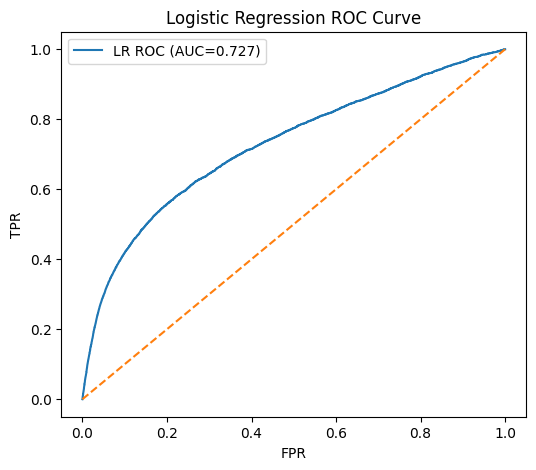

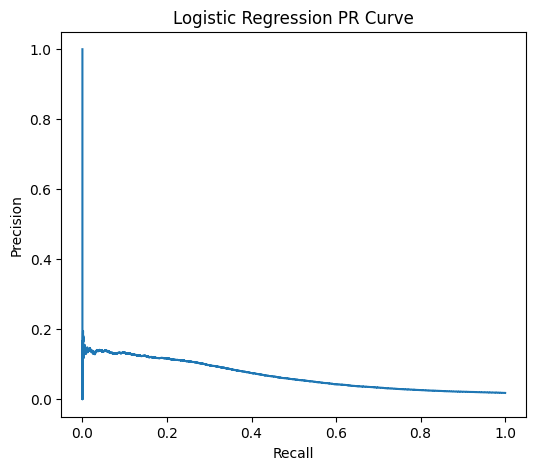

In [67]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

log_model.fit(X_train, y_train)

# Probabilities
y_prob_lr = log_model.predict_proba(X_test)[:, 1]

# ----- Threshold-independent ROC-AUC -----
roc_lr = roc_auc_score(y_test, y_prob_lr)
print("\n===== Logistic Regression (LR) =====")
print("ROC-AUC (probability-based):", roc_lr)

# ----- Metrics at specific thresholds: 0.3, 0.4, 0.45, 0.5 -----
thresholds = [0.3, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    precision_t = precision_score(y_test, y_pred_t)
    recall_t = recall_score(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    specificity_t = tn / (tn + fp)

    print(f"\n[LR] Threshold: {t}")
    print("Confusion Matrix:\n", cm_t)
    print("Precision:", precision_t)
    print("Recall (Sensitivity):", recall_t)
    print("Specificity:", specificity_t)
    print("F1:", f1_t)

# ----- PR curve + F1-based best threshold -----
precision_lr, recall_lr, pr_thresholds_lr = precision_recall_curve(y_test, y_prob_lr)
f1_scores_lr = 2 * (precision_lr * recall_lr) / (precision_lr + recall_lr + 1e-10)
best_idx_lr = np.argmax(f1_scores_lr)
best_threshold_lr = pr_thresholds_lr[best_idx_lr]

print("\n[LR] Best Threshold (F1-based):", best_threshold_lr)
print("[LR] Best F1 Score:", f1_scores_lr[best_idx_lr])

y_pred_lr_best = (y_prob_lr >= best_threshold_lr).astype(int)
cm_lr_best = confusion_matrix(y_test, y_pred_lr_best)
prec_lr_best = precision_score(y_test, y_pred_lr_best)
recall_lr_best = recall_score(y_test, y_pred_lr_best)
f1_lr_best = f1_score(y_test, y_pred_lr_best)
tn, fp, fn, tp = cm_lr_best.ravel()
spec_lr_best = tn / (tn + fp)

print("\n[LR] Confusion Matrix (best F1):\n", cm_lr_best)
print("Precision:", prec_lr_best)
print("Recall:", recall_lr_best)
print("Specificity:", spec_lr_best)
print("F1 Score:", f1_lr_best)

# ----- ROC / PR plots for LR -----
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"LR ROC (AUC={roc_lr:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(recall_lr, precision_lr)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression PR Curve")
plt.show()


#### b. XGBoost model + threshold tuning

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:55:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
ROC-AUC (probability-based): 0.877030901981209

[LR] Threshold: 0.3
Confusion Matrix:
 [[185869 118990]
 [   465   5118]]
Precision: 0.041238276339961966
Recall (Sensitivity): 0.9167114454594304
Specificity: 0.609688413332065
F1: 0.07892606271830736

[LR] Threshold: 0.4
Confusion Matrix:
 [[229644  75215]
 [   931   4652]]
Precision: 0.058246835363792306
Recall (Sensitivity): 0.8332437757478058
Specificity: 0.7532793848959684
F1: 0.10888238736102984

[LR] Threshold: 0.45
Confusion Matrix:
 [[245257  59602]
 [  1169   4414]]
Precision: 0.06895151212196951
Recall (Sensitivity): 0.7906143650367186
Specificity: 0.8044932247366815
F1: 0.12684090288653574

[LR] Threshold: 0.5
Confusion Matrix:
 [[257702  47157]
 [  1452   4131]]
Precision: 0.08054515676181563
Recall (Sensitivity): 0.739924771628157
Specificity: 0.8453153753046491
F1: 0.14527615128976104

[LR] Best Threshold (F1-based): 0.8472747
[LR] Best F1 Score: 0.25845821098137933

[XGB] Confusion Matrix (best F1):
 

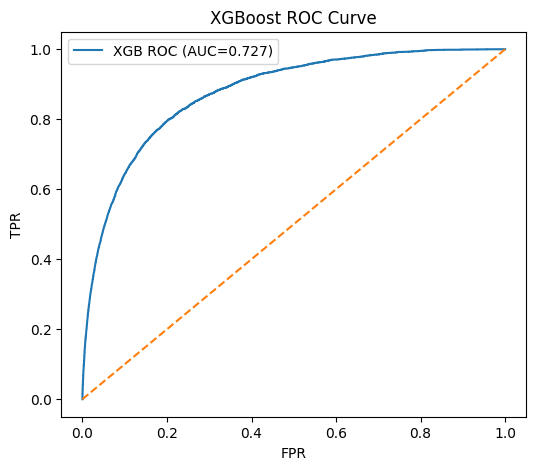

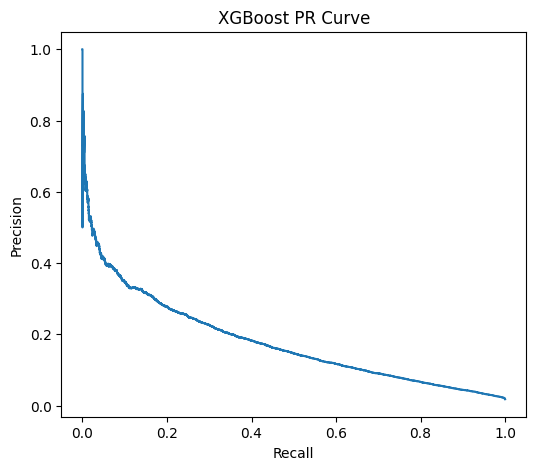

In [68]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ----- Threshold-independent ROC-AUC -----
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("\n===== XGBoost =====")
print("ROC-AUC (probability-based):", roc_xgb)

# ----- Metrics at specific thresholds: 0.3, 0.4, 0.45, 0.5 -----
thresholds = [0.3, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    precision_t = precision_score(y_test, y_pred_t)
    recall_t = recall_score(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    specificity_t = tn / (tn + fp)

    print(f"\n[LR] Threshold: {t}")
    print("Confusion Matrix:\n", cm_t)
    print("Precision:", precision_t)
    print("Recall (Sensitivity):", recall_t)
    print("Specificity:", specificity_t)
    print("F1:", f1_t)

# ----- PR curve + F1-based best threshold -----
precision_xgb, recall_xgb, pr_thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)
f1_scores_xgb = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-10)
best_idx_xgb = np.argmax(f1_scores_xgb)
best_threshold_xgb = pr_thresholds_xgb[best_idx_xgb]

print("\n[LR] Best Threshold (F1-based):", best_threshold_xgb)
print("[LR] Best F1 Score:", f1_scores_xgb[best_idx_xgb])

y_pred_xgb_best = (y_prob_xgb >= best_threshold_xgb).astype(int)
cm_xgb_best = confusion_matrix(y_test, y_pred_xgb_best)
prec_xgb_best = precision_score(y_test, y_pred_xgb_best)
recall_xgb_best = recall_score(y_test, y_pred_xgb_best)
f1_xgb_best = f1_score(y_test, y_pred_xgb_best)
tn, fp, fn, tp = cm_xgb_best.ravel()
spec_xgb_best = tn / (tn + fp)

print("\n[XGB] Confusion Matrix (best F1):\n", cm_xgb_best)
print("Precision:", prec_xgb_best)
print("Recall:", recall_xgb_best)
print("Specificity:", spec_xgb_best)
print("F1 Score:", f1_xgb_best)

# ----- ROC / PR plots for XGB -----
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB ROC (AUC={roc_lr:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(recall_xgb, precision_xgb)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost PR Curve")
plt.show()


#### c. LGBMClassifier model + threshold tuning

[LightGBM] [Info] Number of positive: 22333, number of negative: 1219435
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.593632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7287
[LightGBM] [Info] Number of data points in the train set: 1241768, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== LightGBM (LGBM) =====
ROC-AUC (probability-based): 0.8675617631525673

[LGBN] Threshold: 0.3
Confusion Matrix:
 [[173320 131539]
 [   409   5174]]
Precision: 0.03784570596797671
Recall (Sensitivity): 0.9267418950385098
Specificity: 0.5685251214495882
F1: 0.07272165064372857

[LGBN] Threshold: 0.4
Confusion Matrix:
 [[217338  87521]
 [   827   4756]]
Precision: 0.05154047053978781
Recall (Sensitivity): 0.8518717535375246
Specificity: 0.7129131828156623
F1: 0.09720008174943798

[LGBN] Threshold: 0.45
Confusion Matrix:
 [[234145  70714]
 [  1075   4508]]
Precision: 0.05992927600967802
Recall (Sensitivity): 0.8074511911158875
Specificity: 0.7680435873633384
F1: 0.11157725388280428

[LGBN] Threshold: 0.5
Confusion Matrix:
 [[248232  56627]
 [  1363   4220]]
Precision: 0.06935428205170345
Recall (Sensitivity): 0.7558660218520509
Specificity: 0.8142518344546167
F1: 0.1270510311606202

[LGBM] Best Threshold (F1-based): 0.8384880028600398
[LGBM] Best F1 Score: 0.23304907027255414

[LGBM]

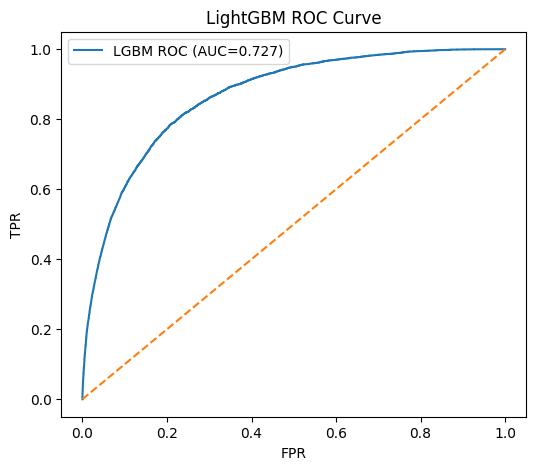

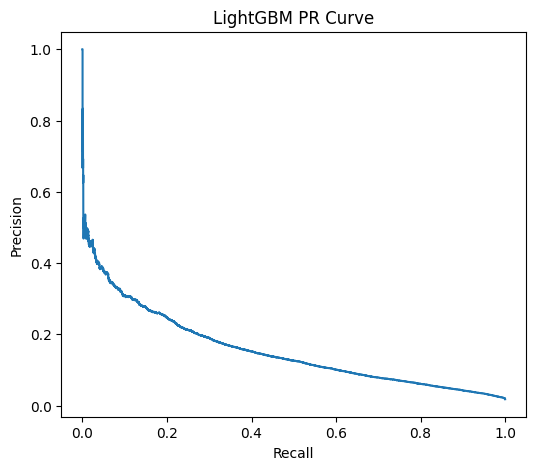

In [69]:
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Probabilities
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# ----- Threshold-independent ROC-AUC -----
roc_lgb = roc_auc_score(y_test, y_prob_lgb)
print("\n===== LightGBM (LGBM) =====")
print("ROC-AUC (probability-based):", roc_lgb)

# ----- Metrics at specific thresholds: 0.3, 0.4, 0.45, 0.5 -----
thresholds = [0.3, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_t = (y_prob_lgb >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    precision_t = precision_score(y_test, y_pred_t)
    recall_t = recall_score(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    specificity_t = tn / (tn + fp)

    print(f"\n[LGBN] Threshold: {t}")
    print("Confusion Matrix:\n", cm_t)
    print("Precision:", precision_t)
    print("Recall (Sensitivity):", recall_t)
    print("Specificity:", specificity_t)
    print("F1:", f1_t)

# ----- PR curve + F1-based best threshold -----
precision_lgb, recall_lgb, pr_thresholds_lgb = precision_recall_curve(y_test, y_prob_lgb)
f1_scores_lgb = 2 * (precision_lgb * recall_lgb) / (precision_lgb + recall_lgb + 1e-10)
best_idx_lgb = np.argmax(f1_scores_lgb)
best_threshold_lgb = pr_thresholds_lgb[best_idx_lgb]

print("\n[LGBM] Best Threshold (F1-based):", best_threshold_lgb)
print("[LGBM] Best F1 Score:", f1_scores_lgb[best_idx_lgb])

y_pred_lgb_best = (y_prob_lgb >= best_threshold_lgb).astype(int)
cm_lgb_best = confusion_matrix(y_test, y_pred_lgb_best)
prec_lgb_best = precision_score(y_test, y_pred_lgb_best)
recall_lgb_best = recall_score(y_test, y_pred_lgb_best)
f1_lgb_best = f1_score(y_test, y_pred_lgb_best)
tn, fp, fn, tp = cm_lgb_best.ravel()
spec_lgb_best = tn / (tn + fp)

print("\n[LGBM] Confusion Matrix (best F1):\n", cm_lgb_best)
print("Precision:", prec_lgb_best)
print("Recall:", recall_lgb_best)
print("Specificity:", spec_lgb_best)
print("F1 Score:", f1_lgb_best)

# ----- ROC / PR plots for LGBM -----
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
plt.figure(figsize=(6,5))
plt.plot(fpr_lgb, tpr_lgb, label=f"LGBM ROC (AUC={roc_lr:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(recall_lgb, precision_lgb)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LightGBM PR Curve")
plt.show()


#### d. 0.4 Threshold tuning

In [70]:
th_final = 0.4

def eval_at_threshold(name, model, X_test, y_test, th=0.4):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= th).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    print(f"\n=== {name} (threshold {th}) ===")
    print("ROC-AUC:", roc)
    print("Confusion Matrix:\n", cm)
    print("Precision:", prec)
    print("Recall:", rec)
    print("Specificity:", spec)
    print("F1 Score:", f1)

    return {
        "model": name,
        "roc": roc,
        "precision": prec,
        "recall": rec,
        "specificity": spec,
        "f1": f1
    }

res_lr  = eval_at_threshold("Logistic Regression", log_model, X_test, y_test, th_final)
res_xgb = eval_at_threshold("XGBoost", xgb_model, X_test, y_test, th_final)
res_lgb = eval_at_threshold("LightGBM", lgb_model, X_test, y_test, th_final)



=== Logistic Regression (threshold 0.4) ===
ROC-AUC: 0.7270805366288622
Confusion Matrix:
 [[150291 154568]
 [  1235   4348]]
Precision: 0.027360366482921797
Recall: 0.7787927637470894
Specificity: 0.4929852817204019
F1 Score: 0.052863543243423974

=== XGBoost (threshold 0.4) ===
ROC-AUC: 0.877030901981209
Confusion Matrix:
 [[229644  75215]
 [   931   4652]]
Precision: 0.058246835363792306
Recall: 0.8332437757478058
Specificity: 0.7532793848959684
F1 Score: 0.10888238736102984


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM (threshold 0.4) ===
ROC-AUC: 0.8675617631525673
Confusion Matrix:
 [[217338  87521]
 [   827   4756]]
Precision: 0.05154047053978781
Recall: 0.8518717535375246
Specificity: 0.7129131828156623
F1 Score: 0.09720008174943798


#### e. Table of 0.4 Threshold tuning

In [71]:
import pandas as pd

results = [res_lr, res_xgb, res_lgb]   #  dict: model, roc, precision, recall, specificity, f1
df_metrics = pd.DataFrame(results)
df_metrics

,model,roc,precision,recall,specificity,f1
0,Logistic Regression,0.727081,0.027360,0.778793,0.492985,0.052864
1,XGBoost,0.877031,0.058247,0.833244,0.753279,0.108882
2,LightGBM,0.867562,0.051540,0.851872,0.712913,0.097200


### 3) XGBoost feature importance vs XGBoost SHAP

#### a. XGBoost feature importance

X_train type: <class 'pandas.core.frame.DataFrame'>
X_test type: <class 'pandas.core.frame.DataFrame'>
Final feature count: 43
Sample features: ['Unnamed: 0' 'Hour' 'HR' 'O2Sat' 'Temp' 'SBP' 'MAP' 'DBP' 'Resp' 'EtCO2']

=== Top 20 XGBoost feature importances===
        feature  importance
0        ICULOS    0.178468
1          FiO2    0.040791
2         EtCO2    0.040566
3            HR    0.039908
4       Lactate    0.039133
5          Resp    0.033907
6         Unit1    0.033735
7          Temp    0.031187
8   HospAdmTime    0.030487
9           MAP    0.029484
10           pH    0.029079
11        Unit2    0.028690
12        PaCO2    0.019877
13          AST    0.019121
14          BUN    0.016057
15         Hour    0.015794
16          DBP    0.015009
17          SBP    0.012723
18          Age    0.012440
19         SaO2    0.012268


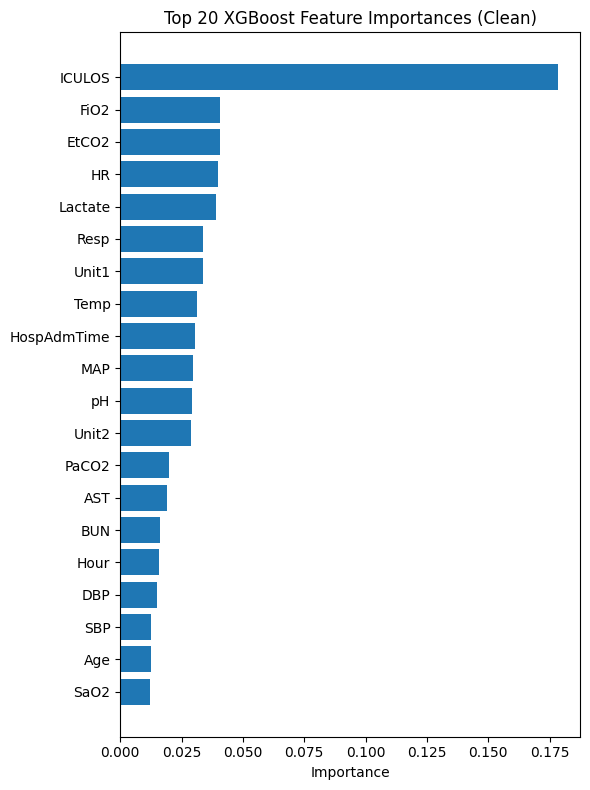

In [79]:
# 1) Separate features and target
X = df.drop("SepsisLabel", axis=1)
y = df["SepsisLabel"]

# 2) Drop rows where target is NaN
mask = y.notna()
X = X[mask]
y = y[mask]

# 3) Drop constant columns
nunique = X.nunique()
constant_cols = nunique[nunique <= 1].index
X = X.drop(columns=constant_cols)

# 4) Train-test split (এখানে X_train এখনো DataFrame)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train type:", type(X_train))
print("X_test type:", type(X_test))


feature_names_original = X_train.columns.to_numpy()

# 5) DataFrame -> numpy (float)
X_train_np = X_train.to_numpy(dtype=float)
X_test_np  = X_test.to_numpy(dtype=float)

# 6) Impute NaNs with train mean
train_mean = np.nanmean(X_train_np, axis=0)

inds_train = np.where(np.isnan(X_train_np))
X_train_np[inds_train] = np.take(train_mean, inds_train[1])

inds_test = np.where(np.isnan(X_test_np))
X_test_np[inds_test] = np.take(train_mean, inds_test[1])

# 7) Remove all-NaN columns (based on train)
all_nan_cols = np.isnan(X_train_np).all(axis=0)
X_train_np = X_train_np[:, ~all_nan_cols]
X_test_np  = X_test_np[:, ~all_nan_cols]


feature_names_non_nan = feature_names_original[~all_nan_cols]

# 8) VarianceThreshold (zero-variance ফিচার বাদ)
selector = VarianceThreshold(threshold=0.0)
X_train_var = selector.fit_transform(X_train_np)
X_test_var  = selector.transform(X_test_np)


feature_names = feature_names_non_nan[selector.get_support()]
print("Final feature count:", len(feature_names))
print("Sample features:", feature_names[:10])

# 9) Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled  = scaler.transform(X_test_var)

# 10) Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
)
xgb_model.fit(X_train_scaled, y_train)


importances = xgb_model.feature_importances_
assert len(feature_names) == len(importances), "Feature name / importance length mismatch!"

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi_df_clean = fi_df[~fi_df['feature'].isin(['Unnamed: 0', 'Patient_ID'])].copy()
fi_df_clean = fi_df_clean.sort_values('importance', ascending=False).reset_index(drop=True)

print("\n=== Top 20 XGBoost feature importances===")
print(fi_df_clean.head(20))

#print("\n=== Top 20 XGBoost feature importances ===")
#print(fi_df.head(20))

plt.figure(figsize=(6, 8))

top20 = fi_df_clean.head(20)
plt.barh(top20["feature"][::-1],
         top20["importance"][::-1])

plt.xlabel("Importance")
plt.title("Top 20 XGBoost Feature Importances (Clean)")
plt.tight_layout()
plt.show()


#### b. XGBoost SHAP

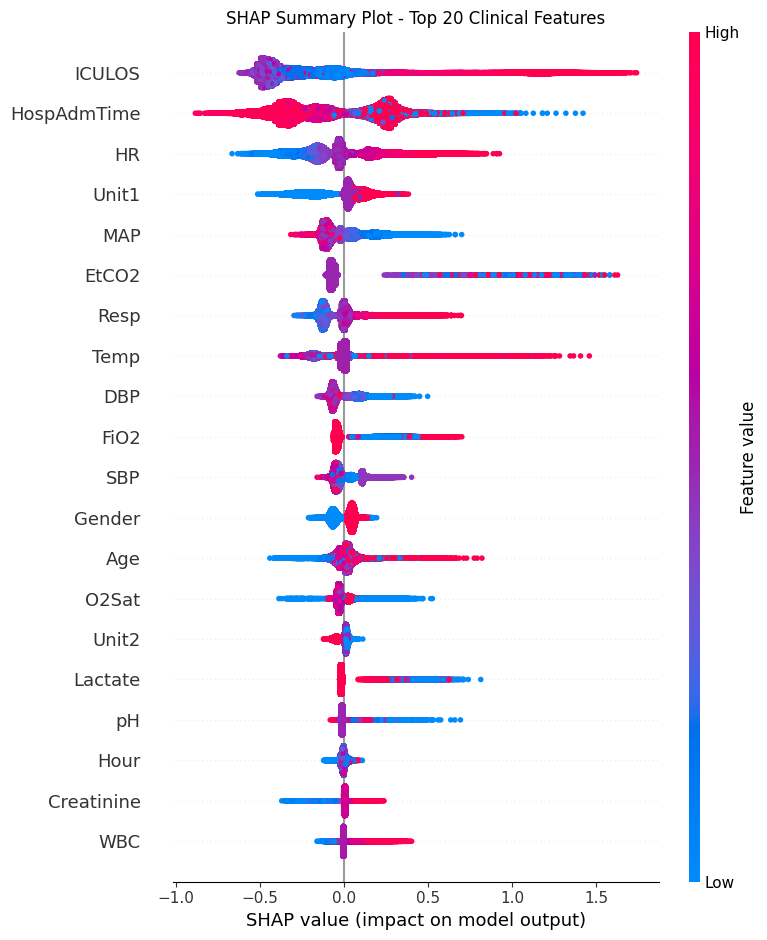

In [73]:
import shap
import numpy as np

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

bad_features = ['Unnamed: 0', 'Patient_ID']
keep_mask = ~np.isin(feature_names, bad_features)

X_clean = X_test_scaled[:, keep_mask]
shap_clean = shap_values[:, keep_mask]
feature_names_clean = feature_names[keep_mask]

shap.summary_plot(
    shap_clean,
    X_clean,
    feature_names=feature_names_clean,
    max_display=20,
    plot_type="dot",
    show=False
)
plt.title("SHAP Summary Plot - Top 20 Clinical Features")
plt.tight_layout()
plt.show()


### 4) Others

#### a. Calibration_curve

Brier score: 0.12737821842507968


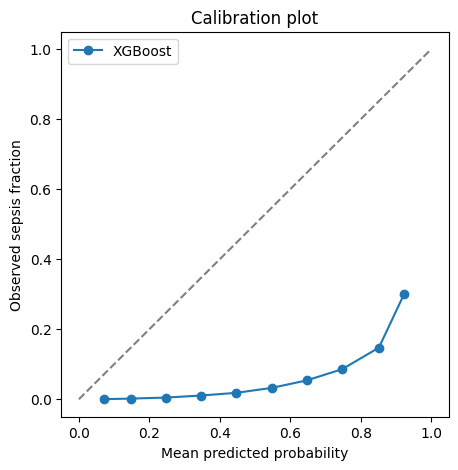

In [74]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

y_prob = y_prob_xgb
brier = brier_score_loss(y_test, y_prob)
print("Brier score:", brier)

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed sepsis fraction")
plt.title("Calibration plot")
plt.legend()
plt.show()

#### b. Risk Stratification

In [75]:
risk = pd.DataFrame({
    "y_true": y_test,
    "y_prob": y_prob
})
risk["risk_group"] = pd.cut(
    risk["y_prob"],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["very low", "low", "medium", "high"]
)

print(risk.groupby("risk_group")["y_true"].mean())
print(risk["risk_group"].value_counts())

risk_group
very low    0.001349
low         0.009448
medium      0.050681
high        0.191730
Name: y_true, dtype: float64
risk_group
low         136107
very low    123047
medium       40429
high         10859
Name: count, dtype: int64


/tmp/ipykernel_839/1922381490.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(risk.groupby("risk_group")["y_true"].mean())


#### c. Age Related Performance

In [76]:
results = []

age_series = df.loc[y_test.index, "Age"]


mask_age_notna = age_series.notna()
age_series = age_series[mask_age_notna]
y_test_clean = y_test[mask_age_notna]
y_prob_clean = y_prob_xgb[mask_age_notna]

for group_name, group_idx in [
    ("Age < 60",  age_series < 60),
    ("Age ≥ 60",  age_series >= 60),
]:
    y_true_g = y_test_clean[group_idx]
    y_prob_g = y_prob_clean[group_idx]
    y_pred_g = (y_prob_g >= 0.4).astype(int)

    roc_g = roc_auc_score(y_true_g, y_prob_g)
    recall_g = recall_score(y_true_g, y_pred_g)

    cm_g = confusion_matrix(y_true_g, y_pred_g).ravel()
    TN, FP, FN, TP = cm_g
    spec_g = TN / (TN + FP)

    results.append([group_name, roc_g, recall_g, spec_g, len(y_true_g)])

subgroup_df = pd.DataFrame(
    results,
    columns=["Group", "AUROC", "Recall", "Specificity", "N"]
)
print(subgroup_df)


      Group     AUROC    Recall  Specificity       N
0  Age < 60  0.885464  0.846154     0.763905  126001
1  Age ≥ 60  0.870958  0.824193     0.746024  184441


#### d. Gender Related Performance

In [77]:
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix
import pandas as pd

results = []

# 1) Gender সিরিজ শুধু test সেট থেকে নাও
gender_series = df.loc[y_test.index, "Gender"]

# 2) Gender-এ NaN থাকলে আগে সেগুলো বাদ দাও
mask_gender_notna = gender_series.notna()
gender_series = gender_series[mask_gender_notna]
y_test_clean = y_test[mask_gender_notna]
y_prob_clean = y_prob_xgb[mask_gender_notna]

# 3) Gender subgroup performance
for label, mask in [
    ("Gender = 1", gender_series == 1), # Male == 1
    ("Gender = 0", gender_series == 0), # Female == 0
]:
    y_true_g = y_test_clean[mask]
    y_prob_g = y_prob_clean[mask]

    n_g = len(y_true_g)
    if n_g == 0:
        print(f"Skip {label}: no samples")
        continue

    y_pred_g = (y_prob_g >= 0.4).astype(int)

    roc_g = roc_auc_score(y_true_g, y_prob_g)
    recall_g = recall_score(y_true_g, y_pred_g)
    TN, FP, FN, TP = confusion_matrix(y_true_g, y_pred_g).ravel()
    spec_g = TN / (TN + FP)

    results.append([label, roc_g, recall_g, spec_g, n_g])

gender_df = pd.DataFrame(
    results,
    columns=["Gender_group", "AUROC", "Recall", "Specificity", "N"]
)
print(gender_df)


  Gender_group     AUROC    Recall  Specificity       N
0   Gender = 1  0.873776  0.843608     0.734587  173654
1   Gender = 0  0.880938  0.818341     0.776956  136788
